# Results - Judge Comparative

The goal of this notebook is to anbalyse the results of the ROUGE-L collections agains the binary judge classifications through the plot of a ROC-AUC curve.  
In this scenario the "true_labesl" will be the evaluations from the judge and the probabilities will be the ROUGE-L scores.



In [1]:
import polars as pl
import json
from sklearn import metrics
import matplotlib.pyplot as plt
import os


In [2]:
def compute_roc_auc_judge_vs_rougel(judge_df, rougel_df):
    """
    Compute and plot ROC-AUC curve comparing judge evaluations against ROUGE-L scores.
    
    Parameters:
    -----------
    judge_df : polars.DataFrame
        Judge dataframe with columns: collection_idx, test_idx, evaluation
    rougel_df : polars.DataFrame
        ROUGE-L dataframe with columns: collection_idx, test_idx, rougel
    
    Returns:
    --------
    float : ROC-AUC score
    """
    # Filter null values and sort
    filtered_judge_df = judge_df.filter(pl.col("evaluation").is_not_null()).sort("collection_idx", "test_idx")
    
    # Join with rougel_df to ensure alignment
    merged_df = filtered_judge_df.join(
        rougel_df.rename({"evaluation": "rougel"}),
        on=["collection_idx", "test_idx"],
        how="inner"
    ).sort("collection_idx", "test_idx")
    
    # Extract labels and scores
    y_true = merged_df["evaluation"].to_list()
    y_scores = merged_df.select(pl.col("rougel")).to_series().to_list()
    
    # Calculate ROC-AUC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve: Judge Evaluation vs ROUGE-L Scores')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    return roc_auc



# Experiment - Instruction Optional Response (only if present in context) 

## Consolidate Rouge-L collections

In [19]:
_train_df= []

for file in os.listdir("../experiment_81_opt/datamodels/collections/train/"):
    if file.endswith(".feather"):
        _train_df.append(pl.read_ipc(os.path.join("../experiment_81_opt/datamodels/collections/train/", file)))


rougel_opt_train_df = pl.concat(_train_df).sort("collection_idx", "test_idx")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [22]:
rougel_opt_train_df.head()

collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
0,0,"[0, 0, … 1]",0.0
0,1,"[0, 0, … 1]",0.0
0,2,"[0, 0, … 1]",0.0
0,3,"[0, 0, … 1]",0.5
0,4,"[0, 0, … 1]",0.0


In [31]:
rougel_opt_train_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())

/tmp/ipykernel_428134/2230130338.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  rougel_opt_train_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())


test_idx,count
i64,u32
3,298
0,215
4,99
6,10
7,15
9,2
1,60
8,8


## Naive Binary Judge

In [28]:
naive_judge_opt_df = pl.read_ipc("../judge_collections/train_opt/naive_judge.feather").sort("collection_idx", "test_idx")

In [30]:
naive_judge_opt_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/2297806497.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  naive_judge_opt_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,1004
null,5208
0,13788


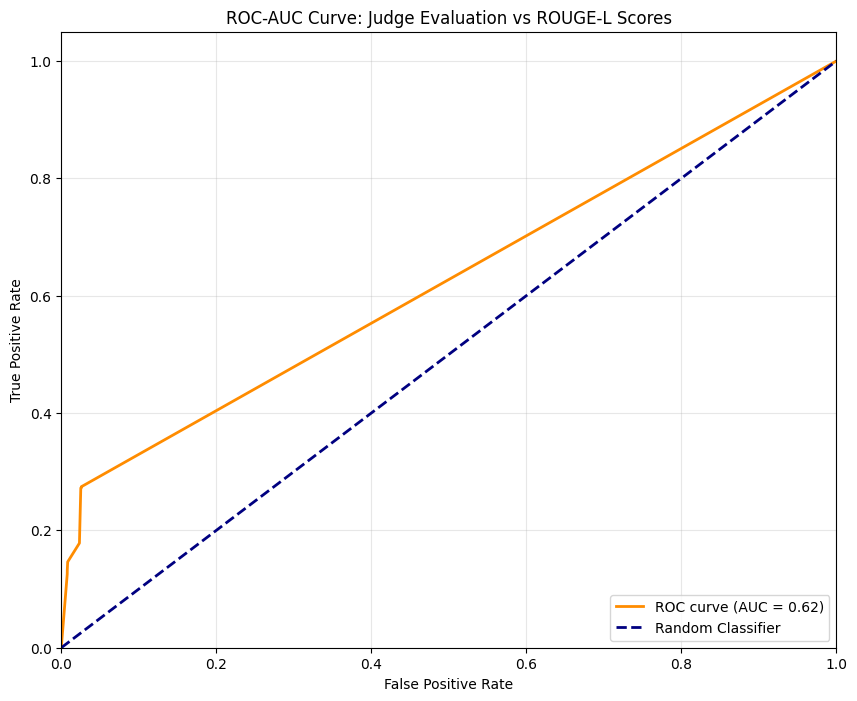

ROC-AUC Score: 0.6243


In [32]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(naive_judge_opt_df, rougel_opt_train_df)

## Naive Binary Recall Judge

In [37]:
recall_naive_opt_judge_df = pl.read_ipc("../judge_collections/train_opt/recall_naive_judge.feather").sort("collection_idx", "test_idx")

In [38]:
recall_naive_opt_judge_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/631711502.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  recall_naive_opt_judge_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
0,15386
1,988
null,3626


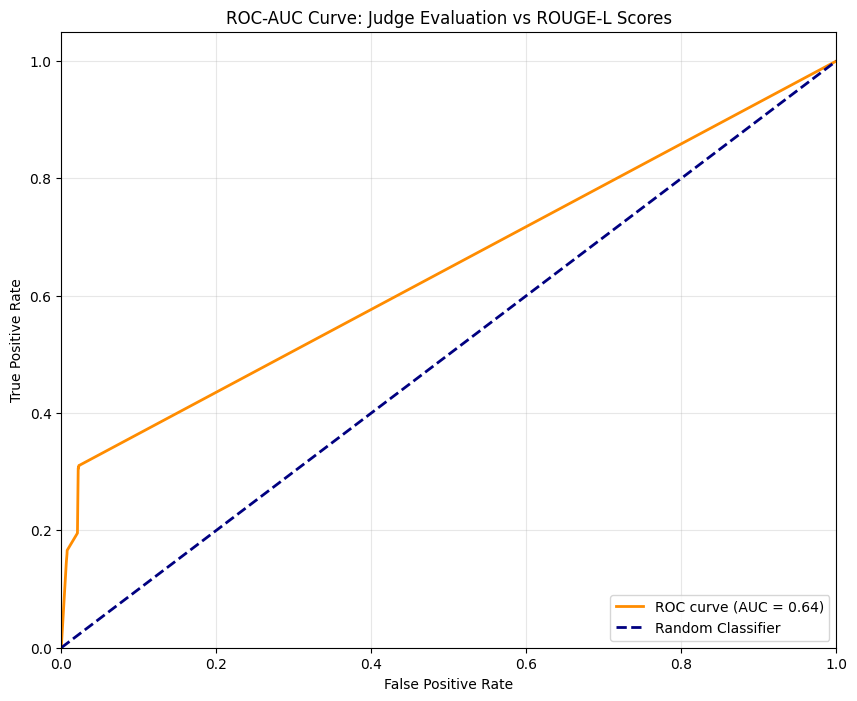

ROC-AUC Score: 0.6439


In [39]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(recall_naive_opt_judge_df, rougel_opt_train_df)

## Pairwise ZeroShot

In [40]:
pairwise_zeroshot_opt_df = pl.read_ipc("../judge_collections/train_opt/pairwise_zeroshot_judge.feather").sort("collection_idx", "test_idx")

In [41]:
pairwise_zeroshot_opt_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/1457708523.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pairwise_zeroshot_opt_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,4518
0,9453
null,6029


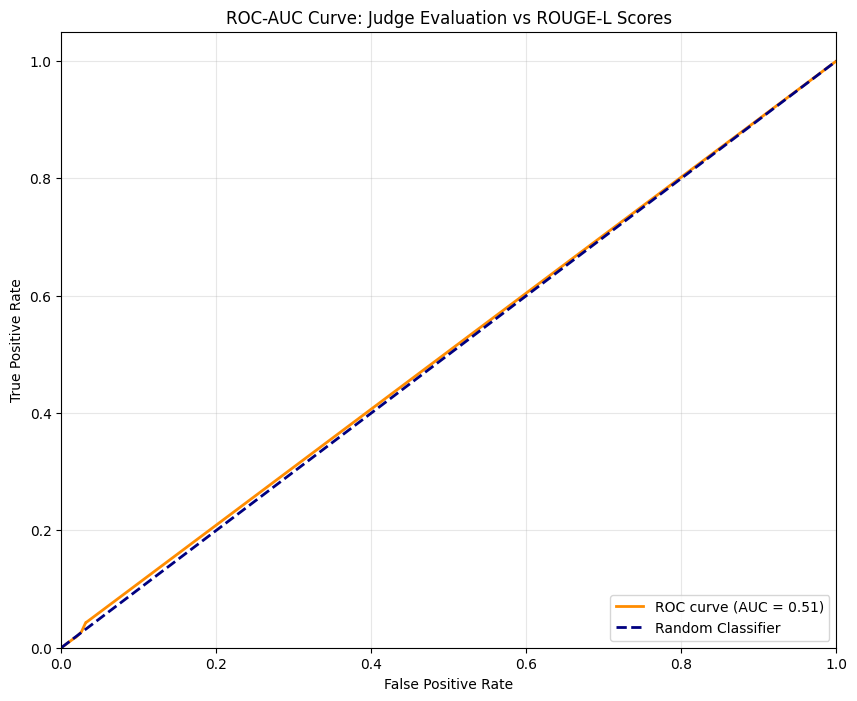

ROC-AUC Score: 0.5053


In [42]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(pairwise_zeroshot_opt_df, rougel_opt_train_df)

## Pairwise RAG

In [43]:
pairwise_rag_opt_df = pl.read_ipc("../judge_collections/train_opt/pairwise_rag_judge.feather").sort("collection_idx", "test_idx")

In [44]:
pairwise_zeroshot_opt_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/1457708523.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pairwise_zeroshot_opt_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,4518
0,9453
null,6029


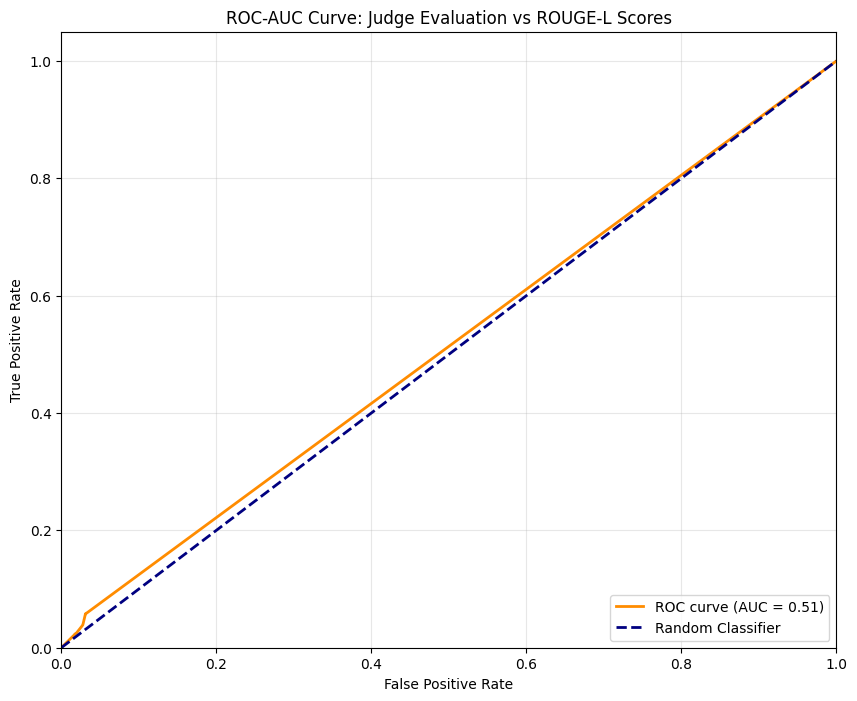

ROC-AUC Score: 0.5129


In [45]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(pairwise_rag_opt_df, rougel_opt_train_df)

# Experiment - Instruction  without specification of Context Usage

## Consolidate Rouge-L collections

In [ ]:
train_df= []
test_df = []

for file in os.listdir("../experiment_81/datamodels/collections/train/"):
    if file.endswith(".feather"):
        train_df.append(pl.read_ipc(os.path.join("../experiment_81/datamodels/collections/train/", file)))

for file in os.listdir("../experiment_81/datamodels/collections/test/"):
    if file.endswith(".feather"):
        test_df.append(pl.read_ipc(os.path.join("../experiment_81/datamodels/collections/test/", file)))

rougel_train_df = pl.concat(train_df).sort("collection_idx", "test_idx")
rougel_test_df = pl.concat(test_df).sort("collection_idx", "test_idx")

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [ ]:
rougel_train_df.head()

collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
0,0,"[0, 0, … 1]",0.285714
0,1,"[0, 0, … 1]",0.0
0,2,"[0, 0, … 1]",0.0
0,3,"[0, 0, … 1]",1.0
0,4,"[0, 0, … 1]",0.0


## Naive Binary Judge

In [ ]:
naive_judge_train_df = pl.read_ipc("../judge_collections/train/naive_judge.feather").sort("collection_idx", "test_idx")

In [ ]:
naive_judge_train_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/3754952104.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  naive_judge_train_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
0,10814
null,2165
1,7021


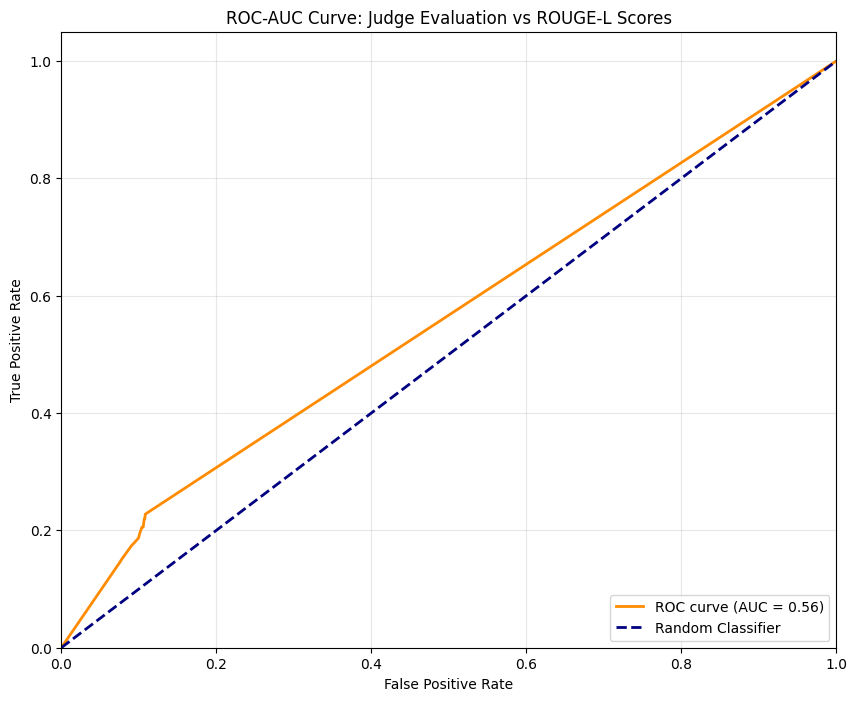

ROC-AUC Score: 0.5586


In [ ]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(naive_judge_train_df, rougel_train_df)

## Naive Binary Recall Judge

In [ ]:
recall_naive_judge_df = pl.read_ipc("../judge_collections/train/recall_naive_judge.feather").sort("collection_idx", "test_idx")

In [ ]:
recall_naive_judge_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/3149426190.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  recall_naive_judge_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
0,9413
1,9421
null,1166


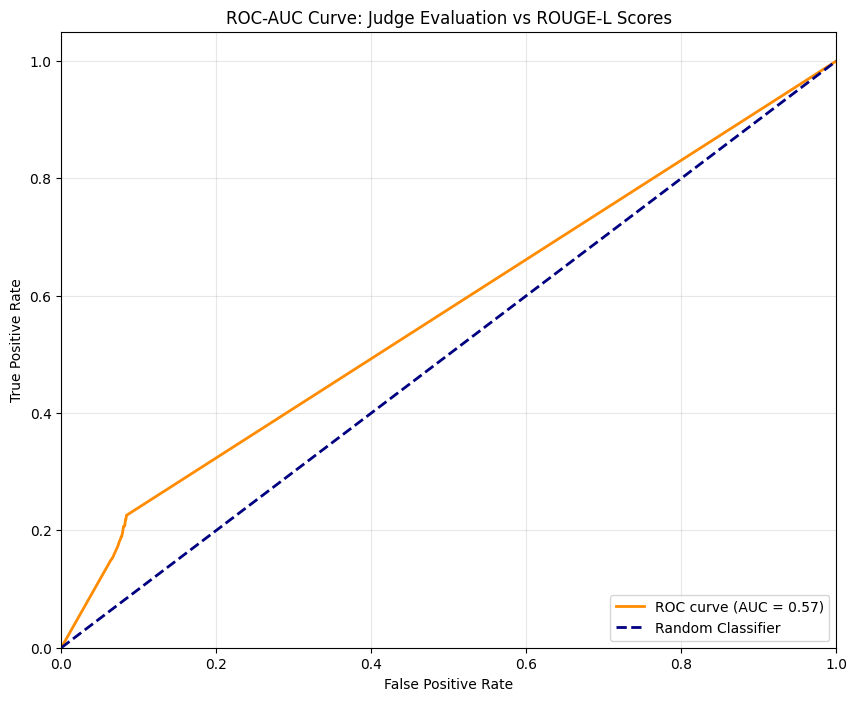

ROC-AUC Score: 0.5697


In [ ]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(recall_naive_judge_df, rougel_train_df)

## Pairwise ZeroShot

In [ ]:
pairwise_zeroshot_df = pl.read_ipc("../judge_collections/train/pairwise_zeroshot_judge.feather").sort("collection_idx", "test_idx")

In [ ]:
pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/958683122.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,1072
1,7171
0,11757


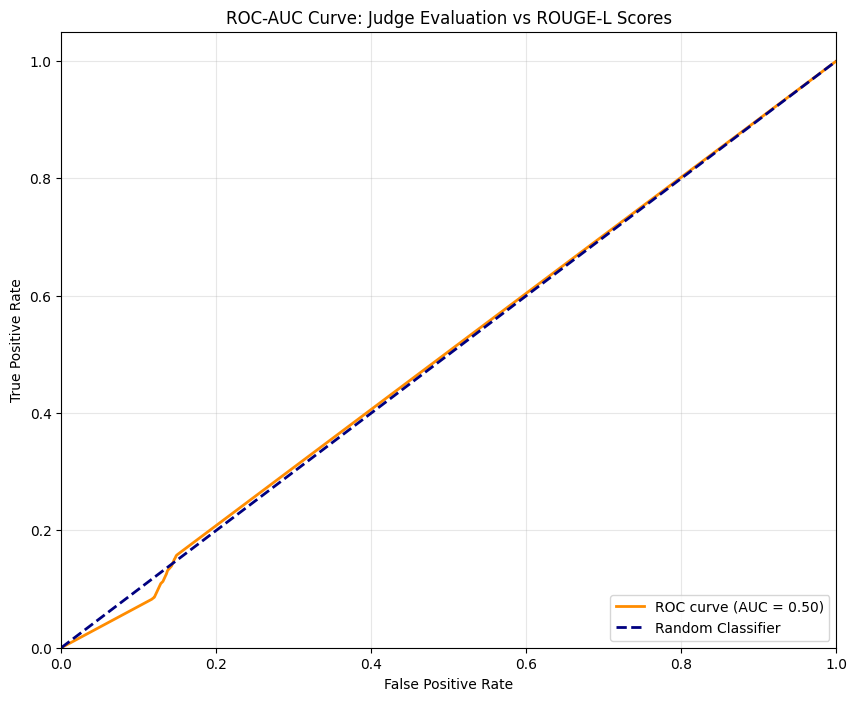

ROC-AUC Score: 0.5013


In [ ]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(pairwise_zeroshot_df, rougel_train_df)

## Pairwise RAG

In [ ]:
pairwise_rag_df = pl.read_ipc("../judge_collections/train/pairwise_rag_judge.feather").sort("collection_idx", "test_idx")

In [ ]:
pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428134/958683122.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
0,11757
null,1072
1,7171


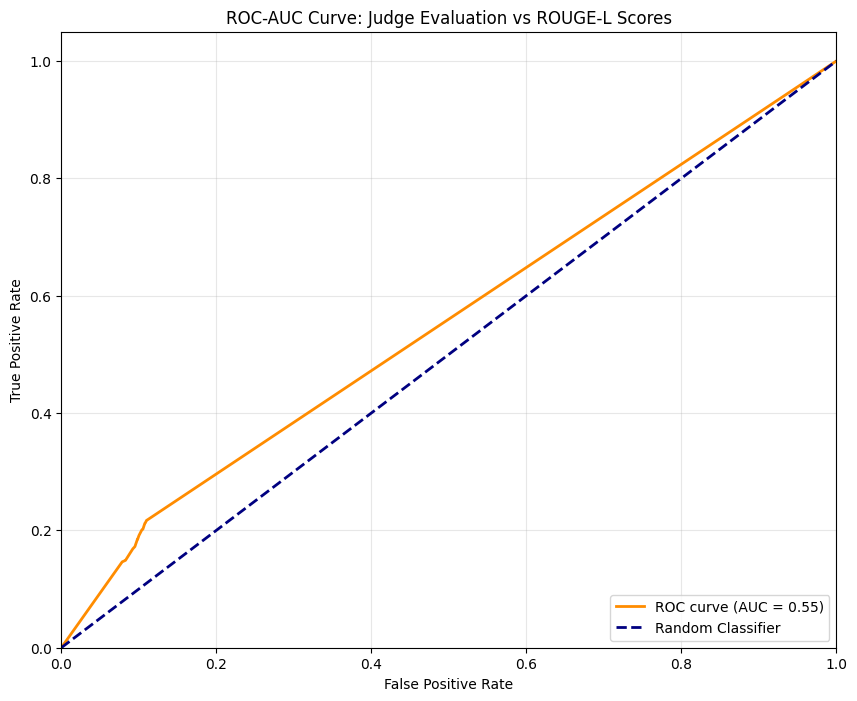

ROC-AUC Score: 0.5528


In [ ]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(pairwise_rag_df, rougel_train_df)

# Experiment - Rouge Instructions without Context Specification with optional in response

## Consolidate Rouge-L collections

In [5]:
_train_df= []

for file in os.listdir("../experiment_81/datamodels/collections/train/"):
    if file.endswith(".feather"):
        _train_df.append(pl.read_ipc(os.path.join("../experiment_81/datamodels/collections/train/", file)))


exp3_rouge_df = pl.concat(_train_df).sort("collection_idx", "test_idx")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [7]:
exp3_rouge_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())

/tmp/ipykernel_428823/902033139.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_rouge_df.filter(pl.col("evaluation")>0).group_by("test_idx").agg(pl.count())


test_idx,count
i64,u32
2,17
6,652
1,258
3,806
0,638
5,40
9,20
4,426
8,184


## Naive Binary Judge

In [12]:
exp3_naive_judge = pl.read_ipc("../judge_collections/train_opt/naive_judge.feather").sort("collection_idx", "test_idx")

In [13]:
exp3_naive_judge.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428823/3383553080.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_naive_judge.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
null,5208
0,13788
1,1004


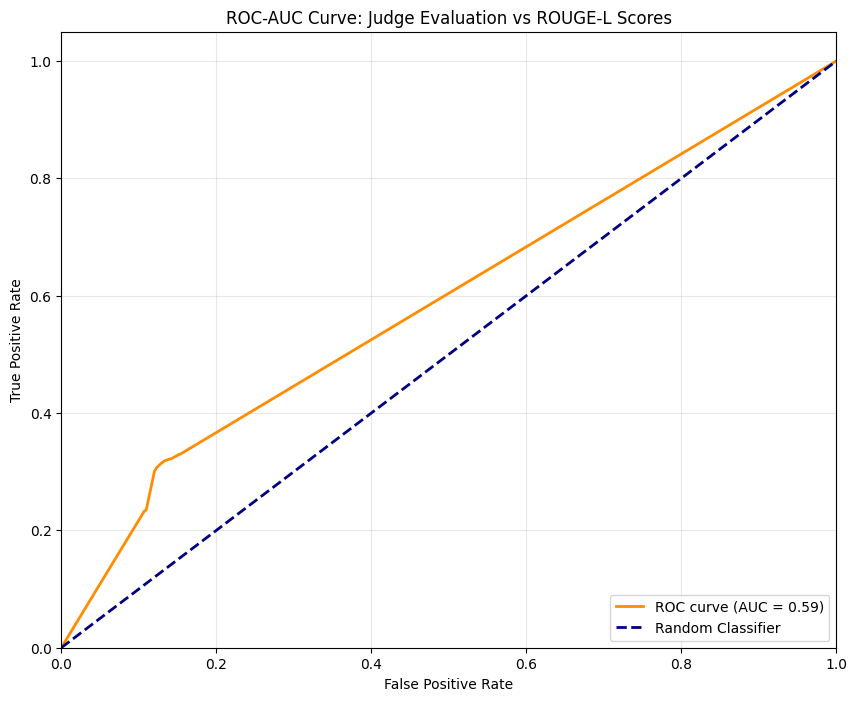

ROC-AUC Score: 0.5894


In [14]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_naive_judge, exp3_rouge_df)

## Naive Binary Recall Judge

In [15]:
exp3_recall_naive_judge_df = pl.read_ipc("../judge_collections/train_opt/recall_naive_judge.feather").sort("collection_idx", "test_idx")

In [16]:
exp3_recall_naive_judge_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428823/1232727256.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_recall_naive_judge_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,988
0,15386
null,3626


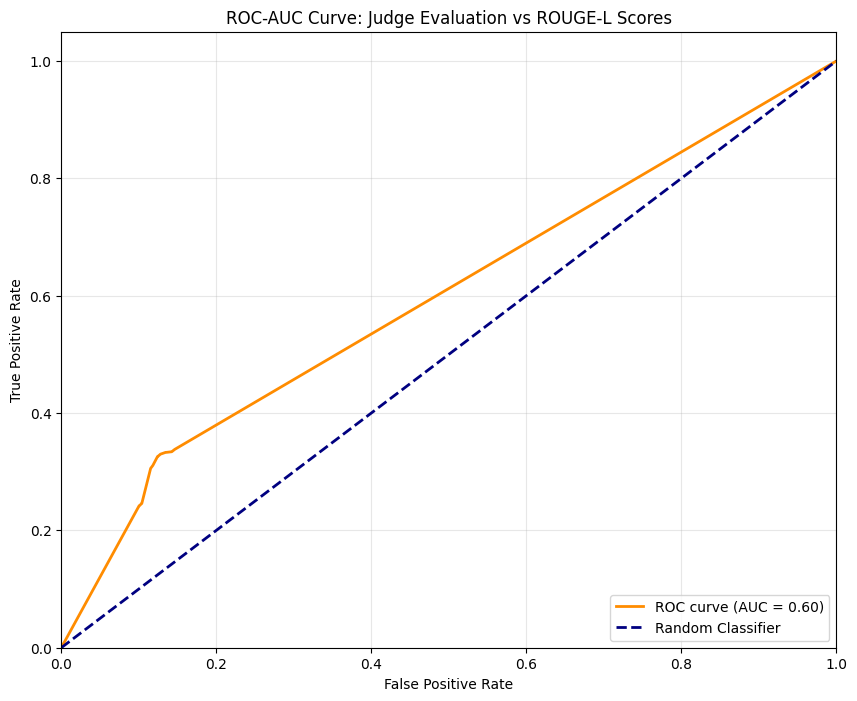

ROC-AUC Score: 0.5974


In [17]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_recall_naive_judge_df, exp3_rouge_df)

## Pairwise ZeroShot

In [18]:
exp3_pairwise_zeroshot_df = pl.read_ipc("../judge_collections/train_opt/pairwise_zeroshot_judge.feather").sort("collection_idx", "test_idx")

In [19]:
exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428823/3667292201.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
0,9453
null,6029
1,4518


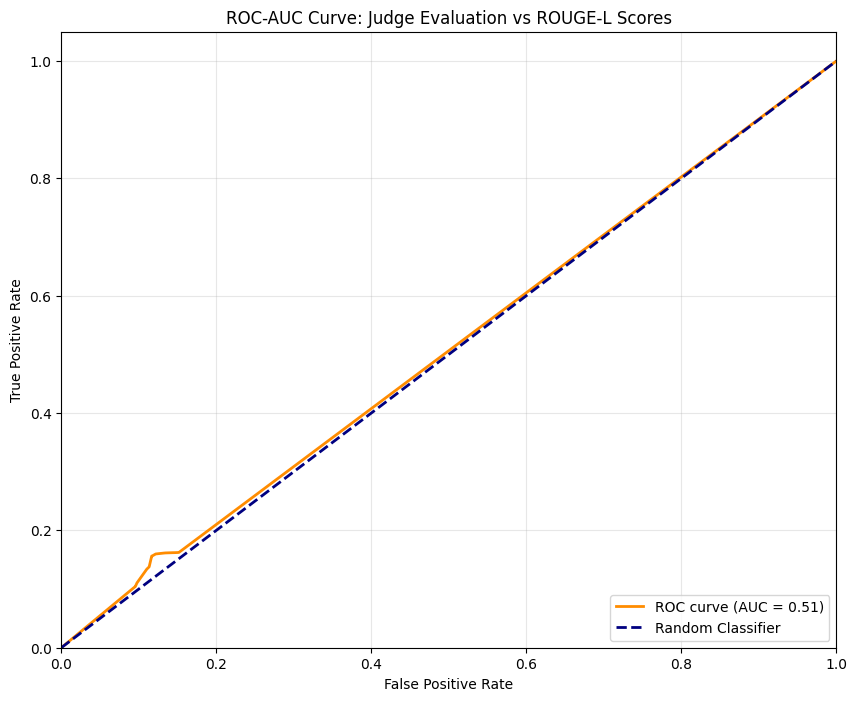

ROC-AUC Score: 0.5063


In [20]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_pairwise_zeroshot_df, exp3_rouge_df)

## Pairwise RAG

In [21]:
exp3_pairwise_rag_df = pl.read_ipc("../judge_collections/train_opt/pairwise_rag_judge.feather").sort("collection_idx", "test_idx")

In [22]:
exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())

/tmp/ipykernel_428823/3667292201.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  exp3_pairwise_zeroshot_df.group_by("evaluation").agg(pl.count())


evaluation,count
i64,u32
1,4518
0,9453
null,6029


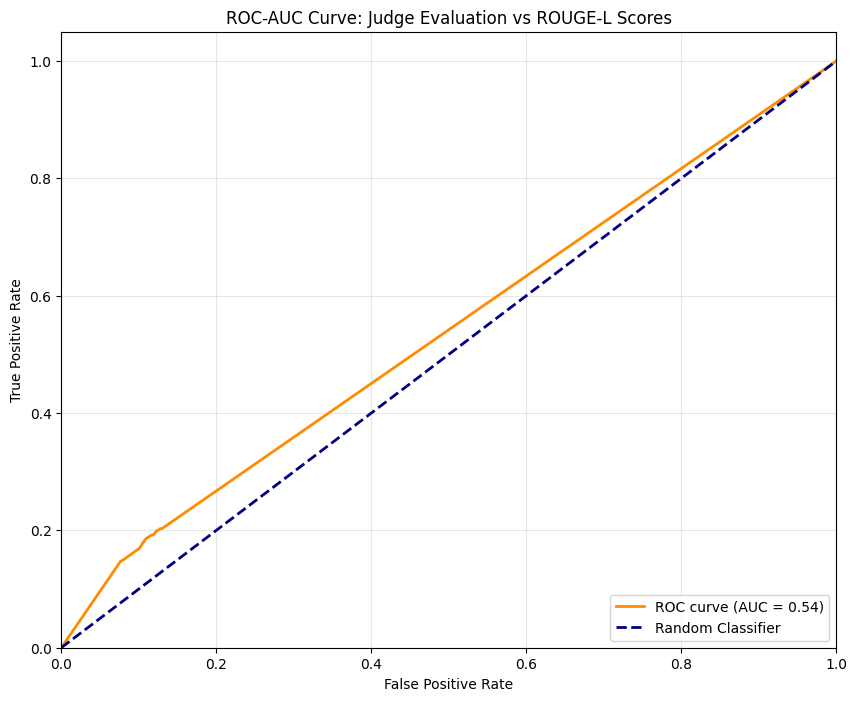

ROC-AUC Score: 0.5384


In [23]:
roc_auc_score = compute_roc_auc_judge_vs_rougel(exp3_pairwise_rag_df, exp3_rouge_df)